# Illustratives Beispiel — Drop-Entscheidung: Myopic+ vs. CFA-Future (Greedy)

**Frage:** Wenn eine Störung eingeschoben werden muss und dafür eine Routine-Station gedroppt werden muss (Cheapest-Insertion infeasible) — *welche* Station droppt Myopic+, und welche droppt CFA-Future, und **warum**?

Beide Modelle nutzen den **gleichen Greedy-Cheapest-Insertion-Mechanismus** (`handle_disruptions_greedy` in `src/planning/greedy_routing.py`). Der Unterschied liegt **nur** in der `drop_score_fn`:

| Modell | `drop_score_fn(node)` | Bedeutung |
|---|---|---|
| **Myopic+** | `power_kW / dist(depot, node)` | Rein geometrisch+Leistung: nahe, leistungsstarke Stationen sind "teuer" zu droppen; **`days_since_maintenance` (dsm) spielt keine Rolle** |
| **CFA-Future** | `C̃(node) = θᵀ·φ_scaled(node)` mit `φ = [power_kW, age_years, recovery_curve(dsm), mean_dist_to_others]` | Berücksichtigt alle 4 Features, u. a. `recovery_curve(dsm)` — **wie überfällig** die Station bereits ist |

Niedrigster Score → wird zuerst gedroppt.

> **In diesem Beispiel verwenden wir die echte CFA-Future-Formel**: `θ`, `feature_means` und `feature_stds` werden direkt aus `data/training/cfa_future/theta.json` geladen (θ = [95, 40, 32, 17] für `[power_kW, age_years, recovery_curve, mean_dist_km]`; der `_value()`-Methode von `cfa_future.py` folgend wird der `intercept` nicht addiert — er würde alle `C̃`-Werte nur um eine Konstante verschieben und die Drop-Reihenfolge nicht ändern). Alle 4 Features fließen mit stationsspezifischen Werten ein: `power_kW`, `dsm`/`recovery_curve`, **und zusätzlich** `age_years` (Alter der Station) sowie `mean_dist` (mittlere Distanz zu anderen Stationen) — letztere beiden sind so gewählt, dass sie die Drop-Entscheidung **verstärken**, ohne sie zu dominieren (Station B ist die jüngste und am stärksten isolierte Station, Station A die älteste und am zentralsten gelegene).
>
> Wichtig: `θ_power=95` ist deutlich größer als `θ_recovery_curve=32` — bei zu großem Leistungsunterschied zwischen den Stationen würde CFA-Future trotz hoher Dringlichkeit dieselbe (leistungsschwache) Station droppen wie Myopic+. Die Stationswerte unten sind so gewählt, dass dieser Effekt **nicht** dominiert.

Das folgende synthetische Grid-Beispiel (4 Stationen A–D, Depot, eine eingehende Störung E) zeigt, dass diese unterschiedliche `drop_score_fn` zu **unterschiedlichen Drop-Entscheidungen** führt — und damit zu unterschiedlichen Ausfallkosten.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ── Synthetisches Grid-Szenario ─────────────────────────────────────────────
# Depot + 4 Routine-Stationen A-D mit unterschiedlicher Leistung (power_kW),
# unterschiedlichem "days_since_maintenance" (dsm), Alter (age_years) und
# mittlerer Distanz zu anderen Stationen (mean_dist, km). Eine Störung E
# tritt weit östlich auf (nahe Station A).
depot = (0, 3)
stations = {
    'A': {'pos': (7, 0), 'power': 11, 'dsm': 350, 'age_years': 12, 'mean_dist': 9},   # AC, fast überfällig, älteste Station
    'B': {'pos': (2, 5), 'power': 30, 'dsm': 20,  'age_years': 3,  'mean_dist': 14},  # AC-Schnelllader, kürzlich gewartet, neu, isoliert
    'C': {'pos': (4, 3), 'power': 22, 'dsm': 150, 'age_years': 7,  'mean_dist': 10},
    'D': {'pos': (3, 6), 'power': 22, 'dsm': 200, 'age_years': 10, 'mean_dist': 12},
}
disruption = {'pos': (8, 1), 'power': 30}

RECOVERY_DAYS = 365
INITIAL_FACTOR = 0.1

def recovery_curve(dsm):
    dsm = min(dsm, RECOVERY_DAYS)
    return INITIAL_FACTOR + (1 - INITIAL_FACTOR) * dsm / RECOVERY_DAYS

def dist(p, q):
    return float(np.hypot(p[0] - q[0], p[1] - q[1]))

# ── Echte CFA-Future-Formel: C̃(node) = θᵀ · φ_scaled(node) ─────────────────
# θ, feature_means, feature_stds aus dem trainierten Modell laden.
with open(Path('..') / 'data' / 'training' / 'cfa_future' / 'theta.json') as f:
    theta_data = json.load(f)

THETA = np.array(theta_data['theta'])              # [power_kW, age_years, recovery_curve, mean_dist_km]
FEATURE_MEANS = np.array(theta_data['feature_means'])
FEATURE_STDS = np.array(theta_data['feature_stds'])

# Alle 4 Features fließen ein — jede Station hat eigene age_years/mean_dist-Werte
# (siehe stations-Dict oben), zusätzlich zu power_kW und recovery_curve(dsm).
def c_tilde(power, dsm, age_years, mean_dist):
    phi = np.array([power, age_years, recovery_curve(dsm), mean_dist])
    phi_scaled = (phi - FEATURE_MEANS) / FEATURE_STDS
    return float(THETA @ phi_scaled)

for name, s in stations.items():
    s['recovery_curve'] = recovery_curve(s['dsm'])
    s['c_tilde'] = c_tilde(s['power'], s['dsm'], s['age_years'], s['mean_dist'])
    # drop_score_fn (current_node = Depot, zum Zeitpunkt der Störung noch nicht
    # abgefahren) — Detour-Term für CFA-Future hier vereinfachend = 0 (C̃ dominiert)
    s['myopic_plus_score'] = s['power'] / max(0.1, dist(depot, s['pos']))
    s['cfa_future_score'] = s['c_tilde']

df = pd.DataFrame(stations).T
df.index.name = 'Station'
print(df[['power', 'dsm', 'age_years', 'mean_dist', 'recovery_curve', 'c_tilde', 'myopic_plus_score', 'cfa_future_score']].round(2))

drop_myopic_plus = min(stations, key=lambda k: stations[k]['myopic_plus_score'])
drop_cfa = min(stations, key=lambda k: stations[k]['cfa_future_score'])
print(f"\nMyopic+    droppt: {drop_myopic_plus} (niedrigster power/dist-Score)")
print(f"CFA-Future droppt: {drop_cfa} (niedrigster C̃-Score)")

        power  dsm age_years mean_dist recovery_curve    c_tilde  \
Station                                                            
A          11  350        12         9       0.963014  -51.59573   
B          30   20         3        14       0.149315  -89.66412   
C          22  150         7        10       0.469863 -79.096571   
D          22  200        10        12       0.593151 -53.918605   

        myopic_plus_score cfa_future_score  
Station                                     
A                1.444371        -51.59573  
B               10.606602        -89.66412  
C                     5.5       -79.096571  
D                 5.18545       -53.918605  

Myopic+    droppt: A (niedrigster power/dist-Score)
CFA-Future droppt: B (niedrigster C̃-Score)


In [2]:
# ── Initialroute (Nearest-Neighbor ab Depot, für beide Modelle identisch) ───
remaining = dict(stations)
route = []
cur = depot
while remaining:
    nxt = min(remaining, key=lambda k: dist(cur, remaining[k]['pos']))
    route.append(nxt)
    cur = remaining[nxt]['pos']
    del remaining[nxt]
print("Initialroute:", " → ".join(['Depot'] + route + ['Depot']))

# Nach Drop: Station wird aus der Route entfernt, Störung E wird am Ende
# eingefügt (Cheapest-Insertion — E liegt nahe der "freigewordenen" Ecke)
route_myopic_plus = [s for s in route if s != drop_myopic_plus] + ['E']
route_cfa = [s for s in route if s != drop_cfa] + ['E']
print("Myopic+    nach Störung:", " → ".join(['Depot'] + route_myopic_plus + ['Depot']))
print("CFA-Future nach Störung:", " → ".join(['Depot'] + route_cfa + ['Depot']))

Initialroute: Depot → B → D → C → A → Depot
Myopic+    nach Störung: Depot → B → D → C → E → Depot
CFA-Future nach Störung: Depot → D → C → A → E → Depot


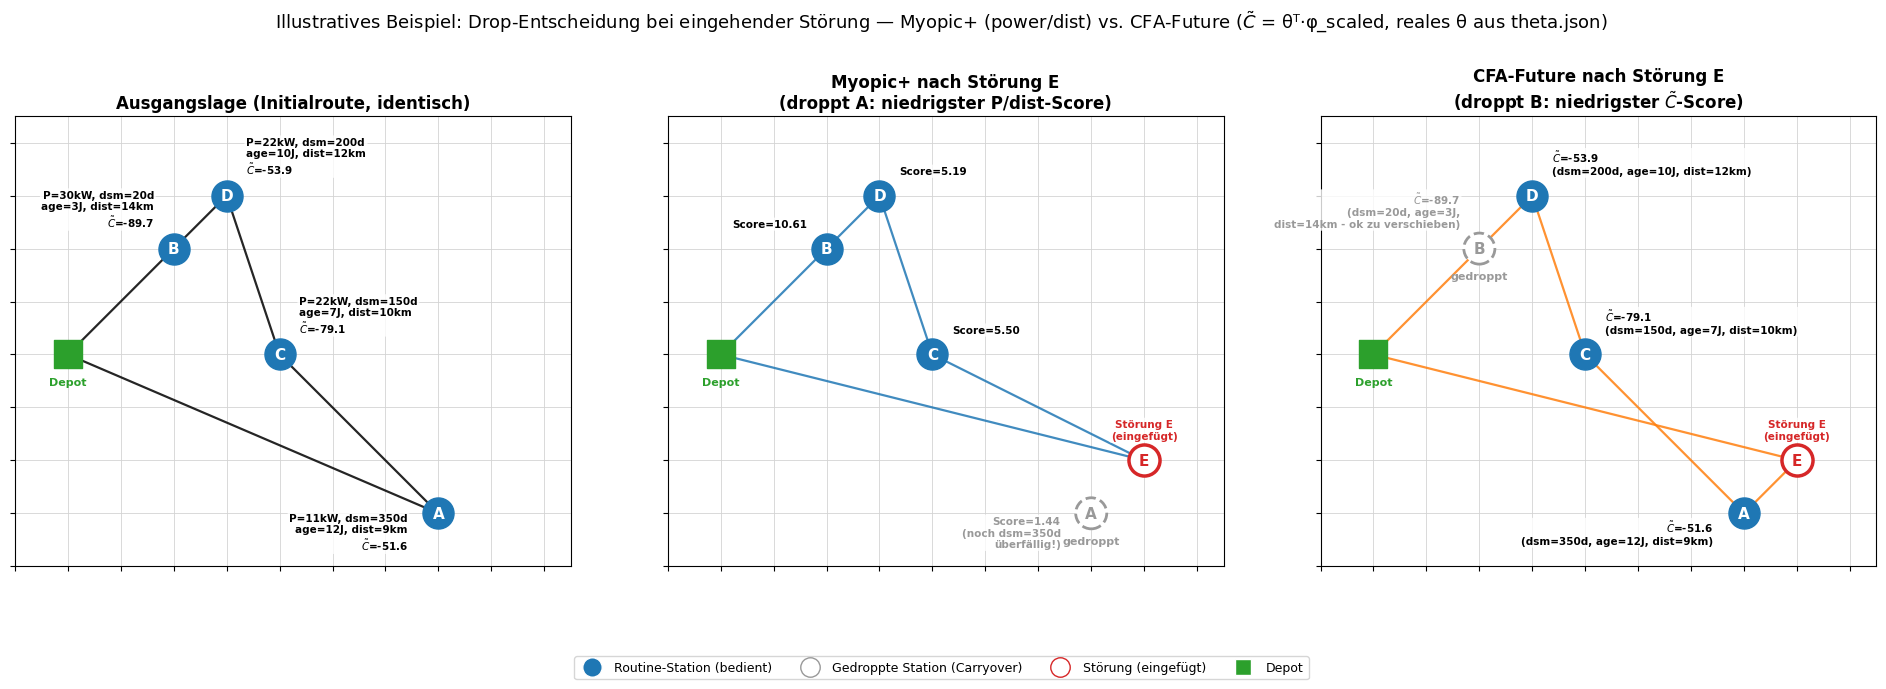

In [3]:
# ── Grid-Visualisierung à la Ulmer et al. (2018), Fig. 1 ────────────────────
STATION_COLOR = '#1f77b4'
DROP_COLOR = '#999999'
DISRUPTION_COLOR = '#d62728'

C_TILDE = r'$\tilde{C}$'

all_points = {**{k: v['pos'] for k, v in stations.items()}, 'E': disruption['pos'], 'Depot': depot}

# Pro Station individuelle Label-Platzierung, um Überlappung mit dem Knoten
# bzw. dem Gridrand zu vermeiden.
LABEL_OFFSETS = {
    'A': dict(dx=-22, dy=-14, ha='right', va='center'),
    'B': dict(dx=-14, dy=14, ha='right', va='bottom'),
    'E': dict(dx=0, dy=14, ha='center', va='bottom'),
}
DEFAULT_OFFSET = dict(dx=14, dy=14, ha='left', va='bottom')

def draw_grid(ax, title):
    ax.set_xlim(-1, 9.5)
    ax.set_ylim(-1, 7.5)
    ax.set_xticks(range(-1, 10))
    ax.set_yticks(range(-1, 8))
    ax.grid(True, color='lightgray', linewidth=0.6)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=12, fontweight='bold')

def draw_route(ax, route_nodes, color='black', linestyle='-'):
    pts = [depot] + [all_points[n] for n in route_nodes] + [depot]
    for i in range(len(pts) - 1):
        ax.annotate('', xy=pts[i+1], xytext=pts[i],
                     arrowprops=dict(arrowstyle='->', color=color, lw=1.6,
                                     linestyle=linestyle, alpha=0.85),
                     zorder=2)

def draw_station(ax, name, dropped=False, is_disruption=False):
    pos = all_points[name]
    if is_disruption:
        ax.scatter(*pos, s=500, marker='o', facecolor='white',
                   edgecolor=DISRUPTION_COLOR, linewidth=2.5, zorder=4)
        ax.annotate(name, pos, ha='center', va='center', fontsize=11,
                    fontweight='bold', color=DISRUPTION_COLOR, zorder=5)
    elif dropped:
        ax.scatter(*pos, s=500, marker='o', facecolor='white',
                   edgecolor=DROP_COLOR, linewidth=2, linestyle='--', zorder=4)
        ax.annotate(name, pos, ha='center', va='center', fontsize=11,
                    fontweight='bold', color=DROP_COLOR, zorder=5)
        ax.annotate('gedroppt', pos, xytext=(0, -22), textcoords='offset points',
                    ha='center', fontsize=8, color=DROP_COLOR, fontweight='bold')
    else:
        ax.scatter(*pos, s=500, marker='o', color=STATION_COLOR, zorder=4)
        ax.annotate(name, pos, ha='center', va='center', fontsize=11,
                    fontweight='bold', color='white', zorder=5)

def draw_depot(ax):
    ax.scatter(*depot, s=400, marker='s', color='#2ca02c', zorder=4)
    ax.annotate('Depot', depot, xytext=(0, -22), textcoords='offset points',
                ha='center', fontsize=8, fontweight='bold', color='#2ca02c')

def annotate_value(ax, name, text, color='black'):
    pos = all_points[name]
    off = LABEL_OFFSETS.get(name, DEFAULT_OFFSET)
    ax.annotate(text, pos, xytext=(off['dx'], off['dy']), textcoords='offset points',
                ha=off['ha'], va=off['va'], fontsize=7.5, color=color, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.8))

fig, axes = plt.subplots(1, 3, figsize=(19, 6.5))

# ── Panel 1: Ausgangslage (identische Initialroute für beide Modelle) ──────
ax = axes[0]
draw_grid(ax, 'Ausgangslage (Initialroute, identisch)')
draw_route(ax, route, color='black')
draw_depot(ax)
for name, s in stations.items():
    draw_station(ax, name)
    annotate_value(ax, name,
                    f"P={s['power']}kW, dsm={s['dsm']}d\n"
                    f"age={s['age_years']}J, dist={s['mean_dist']}km\n"
                    f"{C_TILDE}={s['c_tilde']:.1f}")

# ── Panel 2: Myopic+ nach Störung ───────────────────────────────────────────
ax = axes[1]
draw_grid(ax, f'Myopic+ nach Störung E\n(droppt {drop_myopic_plus}: niedrigster P/dist-Score)')
draw_route(ax, route_myopic_plus, color=STATION_COLOR)
draw_depot(ax)
for name, s in stations.items():
    draw_station(ax, name, dropped=(name == drop_myopic_plus))
    if name == drop_myopic_plus:
        annotate_value(ax, name, f"Score={s['myopic_plus_score']:.2f}\n(noch dsm={s['dsm']}d\nüberfällig!)",
                       color=DROP_COLOR)
    else:
        annotate_value(ax, name, f"Score={s['myopic_plus_score']:.2f}")
draw_station(ax, 'E', is_disruption=True)
annotate_value(ax, 'E', 'Störung E\n(eingefügt)', color=DISRUPTION_COLOR)

# ── Panel 3: CFA-Future nach Störung ────────────────────────────────────────
ax = axes[2]
draw_grid(ax, f'CFA-Future nach Störung E\n(droppt {drop_cfa}: niedrigster {C_TILDE}-Score)')
draw_route(ax, route_cfa, color='#ff7f0e')
draw_depot(ax)
for name, s in stations.items():
    draw_station(ax, name, dropped=(name == drop_cfa))
    if name == drop_cfa:
        annotate_value(ax, name,
                        f"{C_TILDE}={s['c_tilde']:.1f}\n"
                        f"(dsm={s['dsm']}d, age={s['age_years']}J,\n"
                        f"dist={s['mean_dist']}km - ok zu verschieben)",
                        color=DROP_COLOR)
    else:
        annotate_value(ax, name,
                        f"{C_TILDE}={s['c_tilde']:.1f}\n"
                        f"(dsm={s['dsm']}d, age={s['age_years']}J, dist={s['mean_dist']}km)")
draw_station(ax, 'E', is_disruption=True)
annotate_value(ax, 'E', 'Störung E\n(eingefügt)', color=DISRUPTION_COLOR)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=STATION_COLOR, markersize=14,
           label='Routine-Station (bedient)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='white', markeredgecolor=DROP_COLOR,
           markersize=14, label='Gedroppte Station (Carryover)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='white', markeredgecolor=DISRUPTION_COLOR,
           markersize=14, label='Störung (eingefügt)'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#2ca02c', markersize=12, label='Depot'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.06))

fig.suptitle('Illustratives Beispiel: Drop-Entscheidung bei eingehender Störung — '
              rf'Myopic+ (power/dist) vs. CFA-Future ({C_TILDE} = θᵀ·φ_scaled, reales θ aus theta.json)',
              fontsize=13)
plt.tight_layout()
plt.show()

## Interpretation

- **Station A** (AC, 11 kW) ist mit `dsm=350` Tagen fast am Ende des Wartungszyklus (`recovery_curve(A) ≈ 0.96`) — sie ist also **bereits stark überfällig** und ein Ausfall wäre teuer. Außerdem ist A die **älteste** Station (`age_years=12`) und liegt am **zentralsten** zu den anderen Stationen (`mean_dist=9`).
- **Station B** (AC, 30 kW) wurde mit `dsm=20` Tagen **kürzlich gewartet** (`recovery_curve(B) ≈ 0.15`) — ein Aufschub ist hier kaum riskant. B ist außerdem die **jüngste** (`age_years=3`) und am stärksten **isolierte** Station (`mean_dist=14`).

**Myopic+** berücksichtigt beim Drop nur `power_kW / dist(depot, Station)`. Station A liegt weit vom Depot entfernt und hat geringe Leistung → **niedrigster Score (≈1.44) → A wird gedroppt**, obwohl A bereits stark überfällig ist. Das Ergebnis: A wird zum Carryover und fällt potenziell aus, bevor es nachgeholt wird.

**CFA-Future** verwendet die echte gelernte Formel `C̃(node) = θᵀ·φ_scaled(node)` mit `φ = [power_kW, age_years, recovery_curve(dsm), mean_dist_to_others]` und `θ = [95, 40, 32, 17]` aus `data/training/cfa_future/theta.json` — **alle 4 Features tragen mit stationsspezifischen Werten bei**. Trotz geringer Leistung hat A wegen `recovery_curve ≈ 0.96`, hohem `age_years` und niedrigem `mean_dist` einen vergleichsweise hohen `C̃`-Wert (`C̃_A ≈ -51.6`) — deutlich höher (weniger negativ) als das kürzlich gewartete, junge und isolierte B (`C̃_B ≈ -89.7`). **B wird gedroppt statt A.** Das kostet quasi nichts (B ist ja gerade erst gewartet worden), während A planmäßig bedient wird und kein zusätzliches Ausfallrisiko trägt.

> Hinweis: Mit dem ursprünglichen `power_B = 50 kW` würde der `power_kW`-Term (`θ_power=95`) den `recovery_curve`-Term (`θ_recovery_curve=32`) überdecken, sodass CFA-Future ebenfalls A droppen würde (kein Unterschied zu Myopic+). Mit `power_B = 30 kW` — und den zusätzlichen `age_years`/`mean_dist`-Unterschieden, die den Abstand zwischen `C̃_A` und `C̃_B` weiter vergrößern — bleibt B trotz des großen `θ_power`-Gewichts klar die Station mit dem niedrigsten `C̃`. Der Kontrast bleibt erhalten und wird durch die beiden zusätzlichen Features sogar verstärkt.

**Kernaussage:** Myopic+'s Drop-Kriterium ist rein geometrisch/leistungsbezogen und **blind gegenüber der Dringlichkeit (`dsm`), dem Alter und der Lage relativ zu anderen Stationen**. CFA-Future's `C̃` integriert alle 4 Features direkt — dadurch werden in Engpasssituationen tendenziell die Stationen geopfert, die ohnehin gerade gewartet wurden, neu und isoliert sind, statt jene, die kurz vor einem Ausfall stehen, alt und zentral gelegen sind. Genau dieser Effekt erklärt, warum CFA-Future in den Simulationsläufen systematisch niedrigere Ausfallkosten erzielt als Myopic+.

## Zusatzbeispiel: Initialplan-Konstruktion (Greedy Cheapest-Insertion)

Der Unterschied zwischen Myopic+ und CFA-Future beschränkt sich nicht nur auf die Drop-Entscheidung bei Störungen — er beginnt schon bei der **Konstruktion der Initialroute** selbst. `greedy_initial_plan` (`src/planning/greedy_routing.py`) wählt in jedem Schritt aus den verbleibenden Stationen diejenige mit dem **höchsten** `route_score_fn(node, dsm, current_node, matrix)` als nächsten Stopp:

| Modell | `route_score_fn(node, cur)` | Bedeutung |
|---|---|---|
| **Myopic+** | `power_kW(node) / max(1, travel_min(cur, node))` | Nearest-Neighbor, gewichtet mit Leistung: nahe + leistungsstarke Stationen werden früh angefahren — `dsm`/`recovery_curve` spielen **keine Rolle** |
| **CFA-Future** | `(C̃(node) + shift) / max(0.1, dist_km(cur, node))` | Nearest-Neighbor, gewichtet mit `C̃`: Stationen mit hohem `C̃` (hohe `recovery_curve`, also überfällig) werden bevorzugt früh angefahren, auch wenn sie weiter weg liegen |

`shift = max(0, −min(C̃)) + 1` verschiebt alle `C̃`-Werte ins Positive, damit der Score bei kleiner Distanz nicht negativ wird (`greedy_initial_plan`-Implementierung, Kommentar "Shift so that min(C̃) → 1.0").

Mit den gleichen 4 Stationen A–D (und dem bereits geladenen `C_TILDE`/`THETA` aus dem CFA-Future-Beispiel oben) zeigt sich, dass **Myopic+ und CFA-Future bereits unterschiedliche Initialrouten** konstruieren — nicht erst bei der Störung.

In [4]:
# ── Greedy-Initialplan-Konstruktion (Nearest-Neighbor mit Score-Gewichtung) ──
TRAVEL_MIN_PER_KM = 2.0  # ≈ 30 km/h-Äquivalent (Minuten pro Distanzeinheit)

def travel_min(p, q):
    return dist(p, q) * TRAVEL_MIN_PER_KM

# shift wie in CFAFutureModel.create_initial_plan: min(C̃) → 1.0
min_c_tilde = min(s['c_tilde'] for s in stations.values())
shift = max(0.0, -min_c_tilde) + 1.0
print(f"shift = max(0, -min(C̃)) + 1 = {shift:.2f}\n")

def myopic_plus_score(node, cur_pos):
    return stations[node]['power'] / max(1.0, travel_min(cur_pos, stations[node]['pos']))

def cfa_future_score(node, cur_pos):
    return (stations[node]['c_tilde'] + shift) / max(0.1, dist(cur_pos, stations[node]['pos']))

def greedy_construct(score_fn):
    remaining = list(stations.keys())
    cur_pos = depot
    order = []
    while remaining:
        scores = {k: score_fn(k, cur_pos) for k in remaining}
        nxt = max(scores, key=scores.get)
        order.append((nxt, dict(scores)))
        cur_pos = stations[nxt]['pos']
        remaining.remove(nxt)
    return order

order_myopic_plus = greedy_construct(myopic_plus_score)
order_cfa_future = greedy_construct(cfa_future_score)

route_myopic_plus_initial = [n for n, _ in order_myopic_plus]
route_cfa_future_initial = [n for n, _ in order_cfa_future]

print("Myopic+    Initialroute:", " → ".join(['Depot'] + route_myopic_plus_initial + ['Depot']))
print("CFA-Future Initialroute:", " → ".join(['Depot'] + route_cfa_future_initial + ['Depot']))

print("\nScores je Konstruktionsschritt — Myopic+ (power / travel_min):")
for step, (chosen, scores) in enumerate(order_myopic_plus, start=1):
    s = ", ".join(f"{k}={v:.2f}" for k, v in sorted(scores.items()))
    print(f"  Schritt {step}: {s}  → gewählt: {chosen}")

print("\nScores je Konstruktionsschritt — CFA-Future ((C̃+shift) / dist):")
for step, (chosen, scores) in enumerate(order_cfa_future, start=1):
    s = ", ".join(f"{k}={v:.2f}" for k, v in sorted(scores.items()))
    print(f"  Schritt {step}: {s}  → gewählt: {chosen}")

shift = max(0, -min(C̃)) + 1 = 90.66

Myopic+    Initialroute: Depot → B → D → C → A → Depot
CFA-Future Initialroute: Depot → D → A → C → B → Depot

Scores je Konstruktionsschritt — Myopic+ (power / travel_min):
  Schritt 1: A=0.72, B=5.30, C=2.75, D=2.59  → gewählt: B
  Schritt 2: A=0.78, C=3.89, D=7.78  → gewählt: D
  Schritt 3: A=0.76, C=3.48  → gewählt: C
  Schritt 4: A=1.30  → gewählt: A

Scores je Konstruktionsschritt — CFA-Future ((C̃+shift) / dist):
  Schritt 1: A=5.13, B=0.35, C=2.89, D=8.66  → gewählt: D
  Schritt 2: A=5.42, B=0.71, C=3.66  → gewählt: A
  Schritt 3: B=0.14, C=2.73  → gewählt: C
  Schritt 4: B=0.35  → gewählt: B


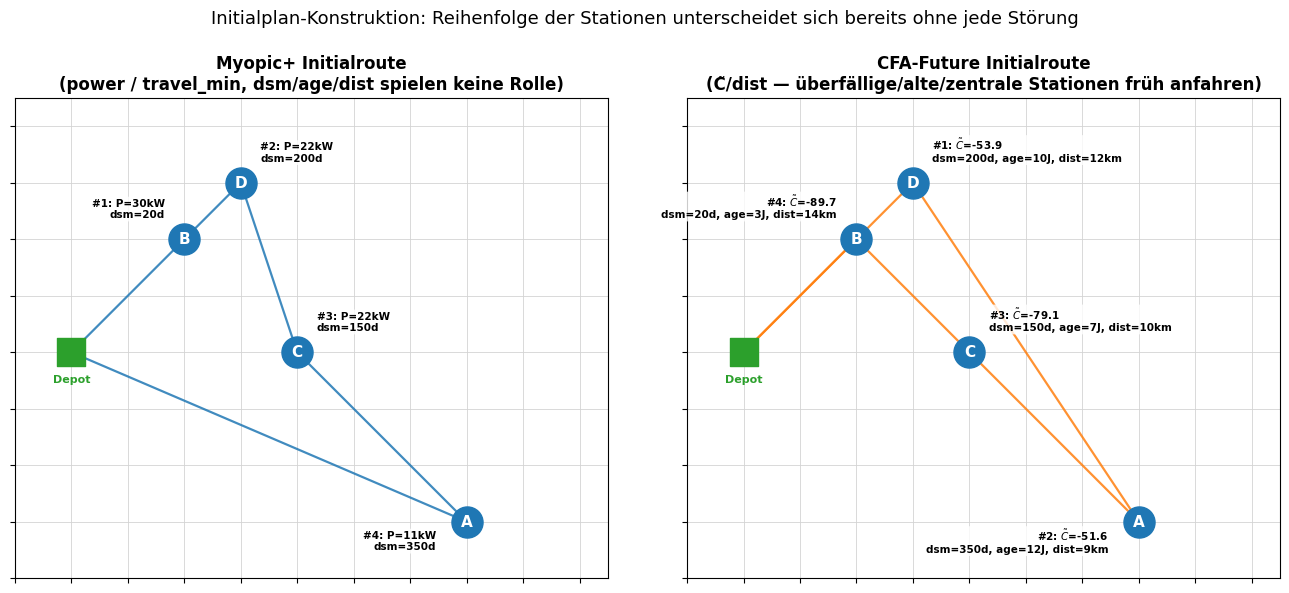

In [5]:
# ── Visualisierung: Initialrouten im Vergleich ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))

ax = axes[0]
draw_grid(ax, 'Myopic+ Initialroute\n(power / travel_min, dsm/age/dist spielen keine Rolle)')
draw_route(ax, route_myopic_plus_initial, color=STATION_COLOR)
draw_depot(ax)
for name, s in stations.items():
    draw_station(ax, name)
    step = route_myopic_plus_initial.index(name) + 1
    annotate_value(ax, name, f"#{step}: P={s['power']}kW\ndsm={s['dsm']}d")

ax = axes[1]
draw_grid(ax, 'CFA-Future Initialroute\n(C̃/dist — überfällige/alte/zentrale Stationen früh anfahren)')
draw_route(ax, route_cfa_future_initial, color='#ff7f0e')
draw_depot(ax)
for name, s in stations.items():
    draw_station(ax, name)
    step = route_cfa_future_initial.index(name) + 1
    annotate_value(ax, name,
                    f"#{step}: {C_TILDE}={s['c_tilde']:.1f}\n"
                    f"dsm={s['dsm']}d, age={s['age_years']}J, dist={s['mean_dist']}km")

fig.suptitle('Initialplan-Konstruktion: Reihenfolge der Stationen unterscheidet sich '
              'bereits ohne jede Störung', fontsize=13)
plt.tight_layout()
plt.show()

### Interpretation: Initialplan

- **Myopic+** baut die Route nach `power_kW / travel_min(cur, node)`: ab Depot ist B (30 kW, nah) am attraktivsten (Score 5.30) → danach D (Score 7.78, sehr nah an B) → C (Score 3.48) → zuletzt **A** (Score 1.30, einzige verbleibende Station). **A — die mit `dsm=350d` bereits am stärksten überfällige (und älteste, zentralste) Station — landet ans Ende der Route**, rein weil sie weit vom Depot entfernt liegt und nur 11 kW hat. `dsm`/`recovery_curve`, `age_years` und `mean_dist` fließen **nirgends** in die Reihenfolge ein.

- **CFA-Future** baut die Route nach `(C̃ + shift) / dist(cur, node)`: ab Depot hat D den höchsten Score (8.66, `C̃_D≈-53.9` ist der zweithöchste `C̃`-Wert und D liegt nah am Depot) → danach **A** (Score 5.42 — trotz der größten Distanz im Beispiel wird A bevorzugt, weil `C̃_A≈-51.6` der höchste `C̃`-Wert aller Stationen ist: überfällig, alt, zentral gelegen) → C (`C̃_C≈-79.1`) → zuletzt B (`C̃_B≈-89.7`, kürzlich gewartet, jung, isoliert — "kann warten").

**Kernaussage:** Myopic+ ordnet die Tagesroute rein nach geometrischer Nähe und Leistung — die überfällige Station A wird zuletzt angefahren (oder bei einer Störung sogar ganz gedroppt, siehe oben). CFA-Future zieht A bewusst **nach vorne** in der Route, obwohl A weit vom Depot entfernt liegt, weil `C̃` die Dringlichkeit (`recovery_curve(dsm)`) sowie Alter und Lage der Station erfasst. Damit wird A frühzeitig bedient und ist — anders als bei Myopic+ — gegen Ende des Tages erst gar nicht mehr "in Gefahr", bei einer Störung gedroppt zu werden.